In [1]:
import urllib
import networkx as nx
import io

# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/network.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 484
  Edges: 7676


In [2]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import powerlaw
from scipy import stats
import math
import copy
import pandas as pd
import networkx as nx

### Part 1: Analyze the network

We analyze the network of rock bands created during the previous exercises. We start off by looking closer at the in and out degrees and the degree distributions.

In [3]:
in_degrees = np.array(list(dict(network.in_degree).values()))
out_degrees = np.array(list(dict(network.out_degree).values()))

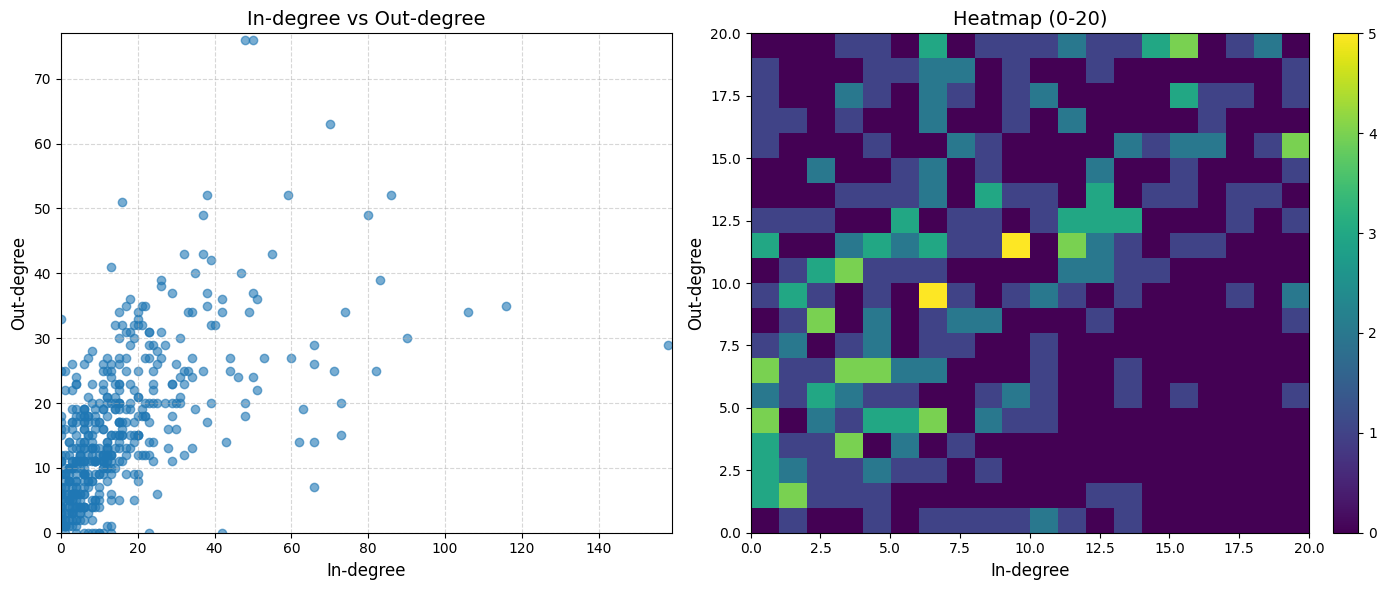

In [4]:
# creating the plots


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# scatter
axes[0].scatter(in_degrees, out_degrees, alpha=0.6)
axes[0].set_title("In-degree vs Out-degree", fontsize=14)
axes[0].set_xlabel("In-degree", fontsize=12)
axes[0].set_ylabel("Out-degree", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].set_xlim(0, max(in_degrees)+1)
axes[0].set_ylim(0, max(out_degrees)+1)

# Heatmap
mask = (in_degrees <= 20) & (out_degrees <= 20)
x = in_degrees[mask]
y = out_degrees[mask]

heatmap, xedges, yedges = np.histogram2d(x, y, bins=20, range=[[0,20],[0,20]])
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im = axes[1].imshow(
    heatmap.T,
    extent=extent,
    origin='lower',
    cmap='viridis',
    interpolation='nearest',
    aspect='auto',
    vmin=0,
    vmax=heatmap.max()  # scale color to counts in 0-20 region only
)

axes[1].set_title("Heatmap (0-20)", fontsize=14)
axes[1].set_xlabel("In-degree", fontsize=12)
axes[1].set_ylabel("Out-degree", fontsize=12)
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 20)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Plot: Relationship between in and out degrees, with a zoomed in heatmap section for the lower degrees.

We created two plots to see the relationship between the incoming and outgoing degrees of the nodes. We see that generally, an increase in the in-degree means an increase in the out-degree, too. Additionally, as visible on the right plot, it is the most common to have a lower number of in and out degrees. The heatmap shows us that the (somewhat) linear trend is also visible here.

We go a bit further into the examples in our network who are outliers regarding this trend: Those with high in-degree and low out-degree number, and vice versa.

In [5]:
# go through all nodes and fix name encoding
decoded_names = {}
for node in network.nodes():
    decoded_name = node.encode('utf-8').decode('unicode_escape')
    decoded_names[node] = decoded_name
network = nx.relabel_nodes(network, decoded_names, copy=False)

In [6]:
in_deg_dict = dict(network.in_degree)
out_deg_dict = dict(network.out_degree)

# define percentiles for high and low degrees
high_in = np.percentile(in_degrees, 80)
low_in = np.percentile(in_degrees, 20)
high_out = np.percentile(out_degrees, 80)
low_out = np.percentile(out_degrees, 20)

In [ ]:
# Identify nodes that are outside
high_in_low_out = [
    (n, in_deg_dict[n], out_deg_dict[n]) for n in network.nodes 
    if in_deg_dict[n] >= high_in and out_deg_dict[n] <= low_out
]

# do the same for low in-degree and high out-degree
low_in_high_out = [
    (n, in_deg_dict[n], out_deg_dict[n]) for n in network.nodes 
    if in_deg_dict[n] <= low_in and out_deg_dict[n] >= high_out
]

In [8]:

print("High in-degree / Low out-degree nodes:")
for node, in_deg, out_deg in high_in_low_out:
    print(f"Node: {node}, In-degree: {in_deg}, Out-degree: {out_deg}")

print("Low in-degree / High out-degree nodes:")
for node, in_deg, out_deg in low_in_high_out:
    print(f"Node: {node}, In-degree: {in_deg}, Out-degree: {out_deg}")

High in-degree / Low out-degree nodes:
Node: zz top, In-degree: 25, Out-degree: 6
Node: motörhead, In-degree: 23, Out-degree: 0
Node: mötley crüe, In-degree: 42, Out-degree: 0
Low in-degree / High out-degree nodes:
Node: alice cooper (band), In-degree: 0, Out-degree: 25
Node: marilyn manson (band), In-degree: 0, Out-degree: 33
Node: the pretty reckless, In-degree: 3, Out-degree: 26
Node: sam fender, In-degree: 1, Out-degree: 25


We can identify that there are some differences between the in and out degrees. Looking into the nodes with high in degrees and low out degrees, we can highlight those artists who were influential for others, but they themselves were not influenced or did not collaborate with the other rock bands. It is important to note that this is not entirely accurate as a model for the real world, as we can only work on the semantics provided by the Wikipedia links and connections. Still, we can identify that, for these nodes, we can typically see earlier artists who simply did not know the upcoming generation during their prime. An example is ZZ Top: when looking at their page, we can't see an 'Influences' section either that sometimes appears with other bands.

Similarly, we have examples of artists who have high out degree numbers, but low in degree. These are the ones who were less influential to others, but frequently mention/collaborate with their peers. On this side, it is more typical to have newer artists who were influenced by the previous generations but are yet to make their mark. Examples here include Sam Fender, The Pretty Reckless. As for Pretty Reckless they have a whole section for Musical style and Influences with a paragraph just referring to other artists:

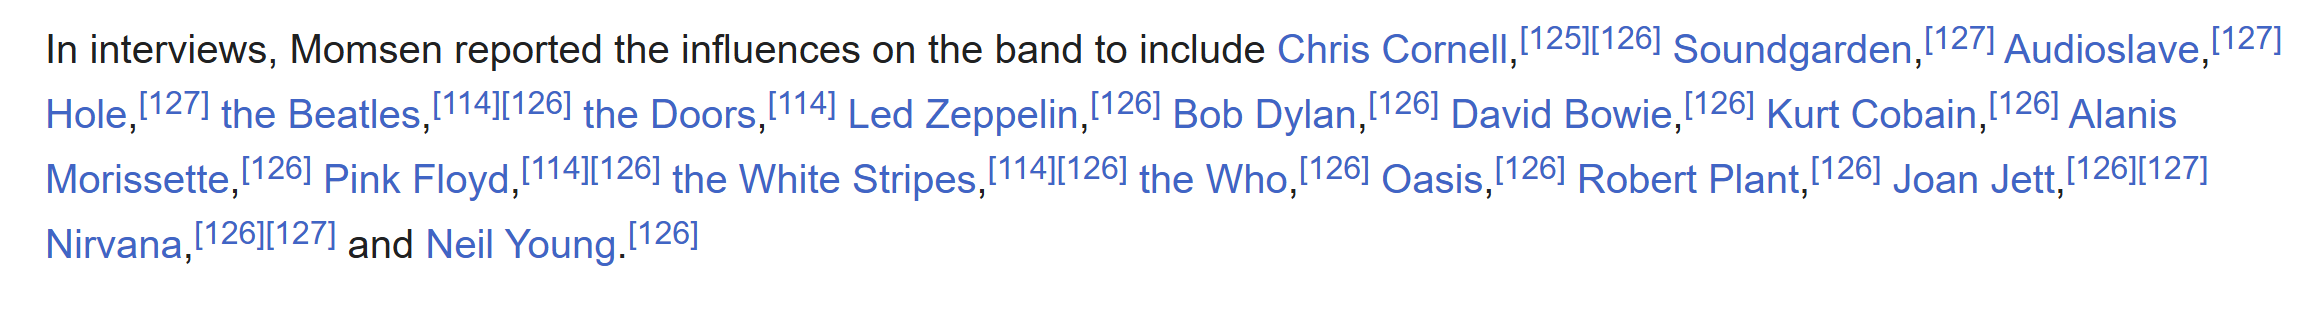

Screenshot taken from https://en.wikipedia.org/wiki/The_Pretty_Reckless#Musical_style_and_influences

Next we will continue to look at the degree distributions.

In [9]:
def degree_distribution(degrees):
    degrees = np.array(degrees)
    # Get unique degree values and their counts
    unique, counts = np.unique(degrees, return_counts=True)
    # Normalize to get probabilities P(k)
    pk = counts / len(degrees)
    return unique, pk

In [10]:
# Get unique degree values and their counts for in-degrees
in_x, in_counts = np.unique(in_degrees, return_counts=True)
in_y = in_counts 

# Get unique degree values and their counts for out-degrees
out_x, out_counts = np.unique(out_degrees, return_counts=True)
out_y = out_counts

We will plot the in-and out degree distributions to see the differences between them, and if they can be characterized by the power-law.

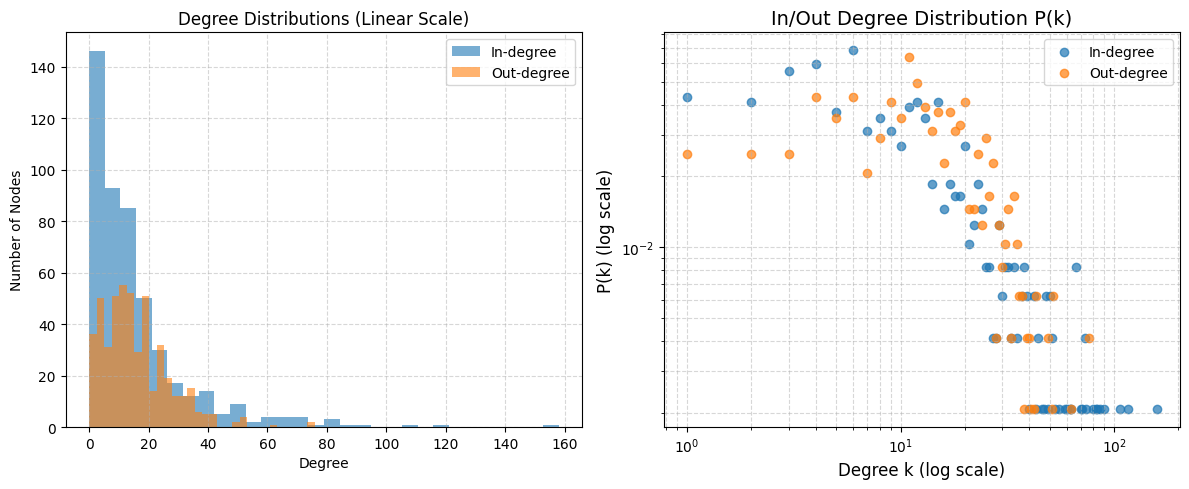

In [11]:


# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(in_degrees, bins=30, alpha=0.6, label='In-degree')
axes[0].hist(out_degrees, bins=30, alpha=0.6, label='Out-degree')
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Number of Nodes")
axes[0].set_title("Degree Distributions (Linear Scale)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)


in_x, in_pk = degree_distribution(in_degrees)
out_x, out_pk = degree_distribution(out_degrees)

axes[1].scatter(in_x, in_pk, label='In-degree', alpha=0.7)
axes[1].scatter(out_x, out_pk, label='Out-degree', alpha=0.7)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel("Degree k (log scale)", fontsize=12)
axes[1].set_ylabel("P(k) (log scale)", fontsize=12)
axes[1].set_title("In/Out Degree Distribution P(k)", fontsize=14)
axes[1].legend()
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)


plt.tight_layout()
plt.show()

To get an initial understanding, we plot the linear and log-log distributions of our network. We observe that both the in-degree and out-degree distributions have longer tails, resembling a power-law distribution, particularly for the in-degrees. The log-log scale shows a more power-law-like drop-off, but we can observe some 'scattering' for the lower degrees, particularly in the out-degree distribution.

In [12]:
# Calculate power-law exponents
in_degree_exponent = round(powerlaw.Fit(in_degrees, xmax=120).alpha, 2)
print("In-degree power-law exponent (alpha):", in_degree_exponent)
out_degree_exponent = round(powerlaw.Fit(out_degrees).alpha, 2)
print("Out-degree power-law exponent (alpha):", out_degree_exponent)

degrees = np.array(list(dict(network.degree).values()))
full_degree_exponent = round(powerlaw.Fit(degrees, xmax=120).alpha, 2)
print("Full-degree power-law exponent (alpha):", full_degree_exponent)

Calculating best minimal value for power law fit
In-degree power-law exponent (alpha): 2.64
Calculating best minimal value for power law fit
Out-degree power-law exponent (alpha): 6.01
Calculating best minimal value for power law fit
Full-degree power-law exponent (alpha): 3.99


Values less than or equal to 0 in data. Throwing out 0 or negative values
Values less than or equal to 0 in data. Throwing out 0 or negative values


The degree exponent for the whole network is 3.99 which indicates that the small world property is present, but the network is harder to distinguish from a random network. As also highlighted in the book (*): this network already falls into the random regime.

The book also states that the higher this degree exponent gets the less distinguishable it is from a random network. In our findings the In-degree exponent is lower compared to the out-degree exponent. This is also in line with previous research where they investigate multiple wikipedia networks and find that the the exponent is generally lower for the in than the out-degree. (**)
In our case the in-degree exponent places the network in the scale-free regime, characterized as an 'ultra-small world'.


(*) https://networksciencebook.com/chapter/4#degree-exponent

(**) https://journals.aps.org/pre/abstract/10.1103/PhysRevE.74.016115

Next we analyze if the length of the page has any correlation with the degrees.

In [13]:
# for each node add a length_of_content attribute
for node, attrs in network.nodes(data=True):
    content = attrs.get("content", "")
    length_of_content = len(content)
    network.nodes[node]["length_of_content"] = length_of_content

In [14]:
# extract lengths and out-degrees
lengths = np.array([attrs["length_of_content"] for _, attrs in network.nodes(data=True)])
out_degrees = np.array(list(dict(network.out_degree).values()))

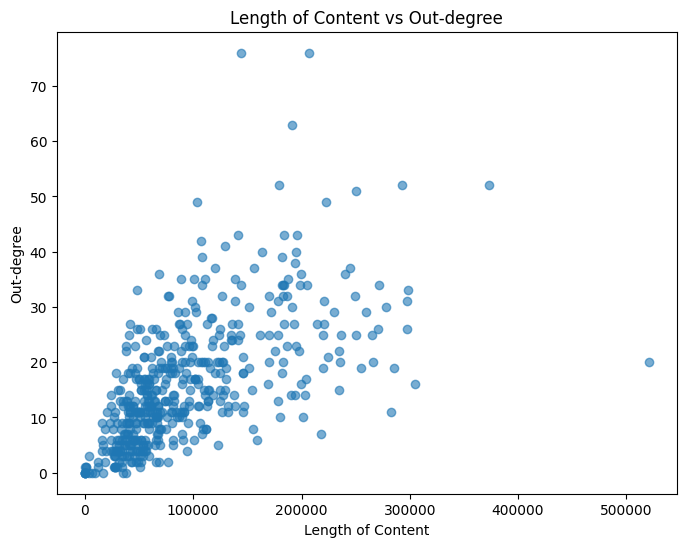

In [15]:
# plot length of content vs out degree
plt.figure(figsize=(8,6))
plt.scatter(lengths, out_degrees, alpha=0.6)
plt.xlabel("Length of Content")
plt.ylabel("Out-degree")
plt.title("Length of Content vs Out-degree")
plt.show()


The plot shows that there seems to be a direct correlation between the two attributes, we will quantify this in the following section.

In [16]:
import scipy.stats as stats

corr_coef, p_value = stats.pearsonr(lengths, out_degrees)
print(f"Pearson correlation coefficient (out-degrees): {corr_coef:.4f}, p-value: {p_value:.4e}")

corr_coef, p_value = stats.pearsonr(lengths, in_degrees)
print(f"Pearson correlation coefficient (in-degrees): {corr_coef:.4f}, p-value: {p_value:.4e}")

Pearson correlation coefficient (out-degrees): 0.6134, p-value: 2.2886e-51
Pearson correlation coefficient (in-degrees): 0.0383, p-value: 4.0091e-01


We observed that there is correlation between the length of texts and both the in and out links. The correlation between the number of out degrees and the length of the text is slightly higher. This reinforces our observation that a longer text is more likely to contain links. The other correlation is harder to observe, but the data shows that there is indeed a correlation between how long a Wikipedia article for a band is and how "famous" or referenced they are. This shows that more famous bands tend to have a more detailed Wikipedia page.

Now we analyze the network more deeply with the help of some centrality metrics.

In [17]:
# Calculate degree centrality
degree_centrality = nx.degree_centrality(network)
sorted_by_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(network)
sorted_by_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)


We also visualize the network where the artists with higher betweenness centrality will be larger to see which are the crucial points that have a lot of shortest paths flowing through.

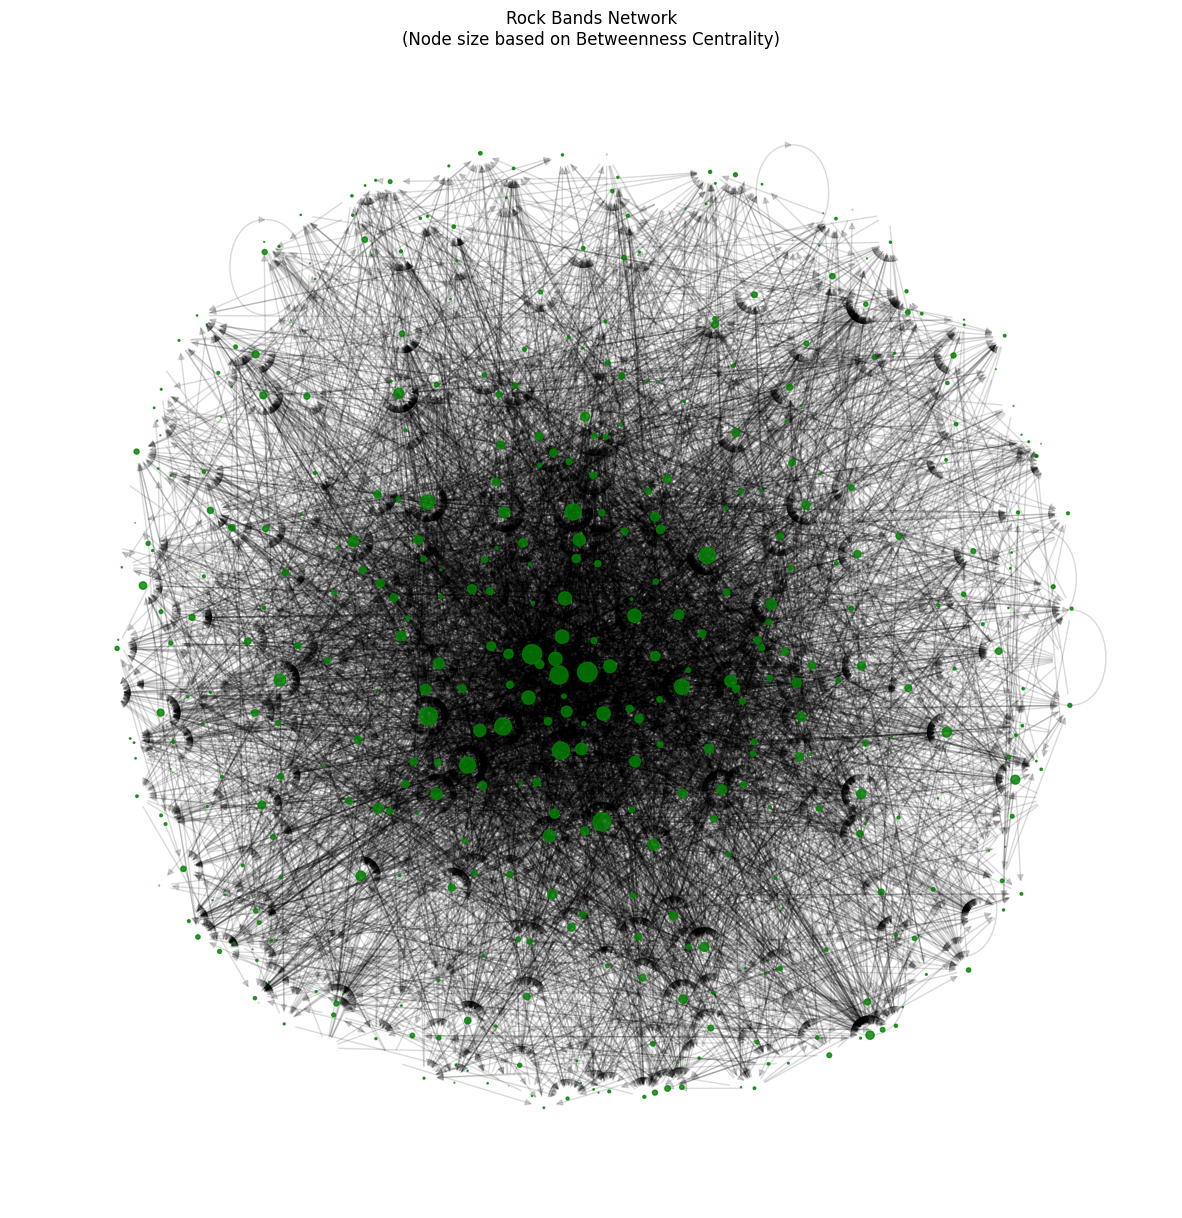

In [18]:
# Create a new figure with a larger size
plt.figure(figsize=(15, 15))

pos = nx.spring_layout(network, k=1, iterations=50)

node_sizes = [betweenness_centrality[node] * 5000 for node in network.nodes()] 
nx.draw_networkx_nodes(network, pos, node_size=node_sizes, node_color='green', alpha=0.8)

nx.draw_networkx_edges(network, pos, alpha=0.15)

plt.title("Rock Bands Network\n(Node size based on Betweenness Centrality)")
plt.axis('off')
plt.show()

The visualization shows that we have a network-core that contains a high number of nodes with large betweenness centrality. A shortest reference path likely flows through one of the elements of these core artists when we connect two bands from e.g. the 'peripherals'.

As a next step we identify who these artists are.

In [19]:
print("Top 5 artists by degree centrality:")
for char, centrality in sorted_by_degree[:5]:
    print(f"{char}: {centrality:.4f}")

print("\nTop 5 artists by betweenness centrality:")
for char, centrality in sorted_by_betweenness[:5]:
    print(f"{char}: {centrality:.4f}")

Top 5 artists by degree centrality:
the beatles: 0.3872
led zeppelin: 0.3126
the rolling stones: 0.2899
queen (band)|queen: 0.2857
black sabbath: 0.2754

Top 5 artists by betweenness centrality:
deep purple: 0.0396
queen (band)|queen: 0.0384
alice in chains: 0.0341
the rolling stones: 0.0332
guns n' roses: 0.0332



Looking at the results, we can observe that the network shows interesting patterns, both in degree and betweenness centrality:

Degree centrality showcases nodes that have a large amount of connections. In our network, Beatles and Led Zeppelin, and The Rolling Stones have the highest score, which shows that they indeed have a high influence in the network as famous bands.

Betweenness centrality, on the other hand, shows which bands act as bridges between other nodes (if they are part of many shortest paths in the network). Here, the top scorers are Deep Purple and Queen. Looking at the Wikipedia site of Queen, we can see that the band is active from 1970-to the present. This is an indicator that the band is a connector of different eras, too.

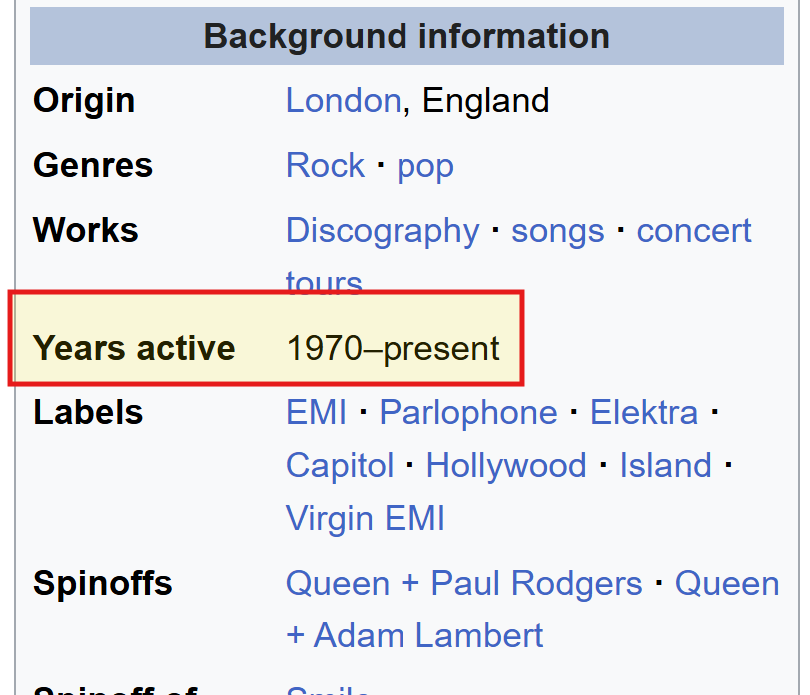

Similarly with deep purple we can also observe that they covered 2 different eras during their years active:

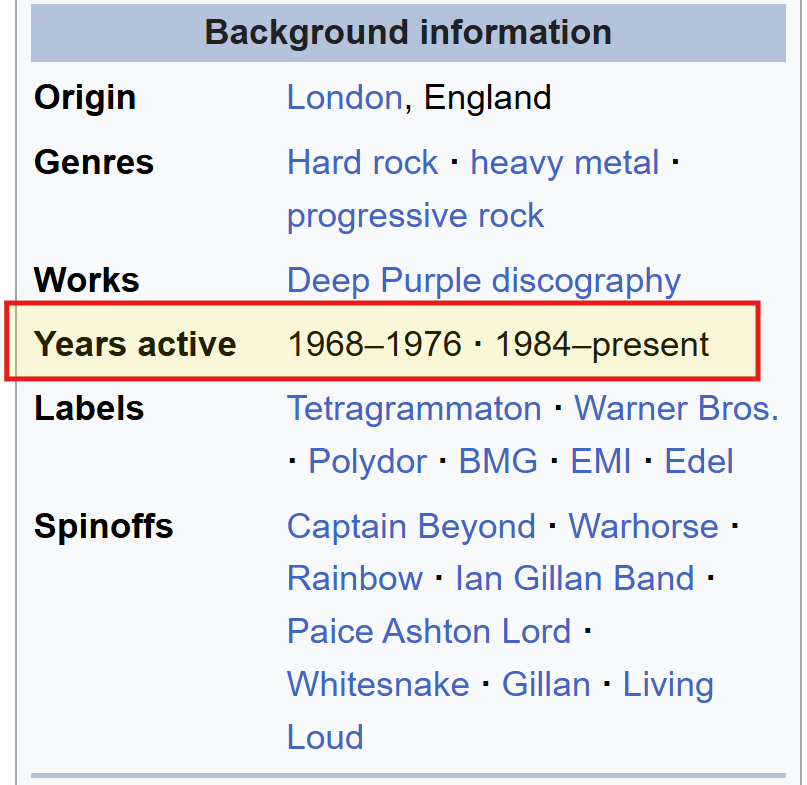
Additionally, their page says "They are considered to be among the pioneers of heavy metal and modern hard rock". This shows that they had influence across multiple genres. This aligns with our findings regarding their centrailty.



Next we will look at another bit more sophisticated measure, which is the eigen-centrality. Compared to degree centrality, this metric also takes into account how important are the neighbors of a given node.

In [20]:

# eigen_in computes centrality on the reversed graph

eigen_out = nx.eigenvector_centrality(network, max_iter=2000)
eigen_in = nx.eigenvector_centrality(network.reverse(), max_iter=2000)


In [21]:

sorted_eig_out = sorted(eigen_out.items(), key=lambda x: x[1], reverse=True)
sorted_eig_in = sorted(eigen_in.items(), key=lambda x: x[1], reverse=True)

print("Top 5 by eigenvector centrality (out-edges / normal adjacency):")
for n, v in sorted_eig_out[:5]:
    print(f"{n}: {v:.4f}")

print("\nTop 5 by eigenvector centrality (in-edges / reversed adjacency):")
for n, v in sorted_eig_in[:5]:
    print(f"{n}: {v:.4f}")

Top 5 by eigenvector centrality (out-edges / normal adjacency):
the beatles: 0.2747
led zeppelin: 0.2036
the rolling stones: 0.1943
the who: 0.1718
bob dylan: 0.1709

Top 5 by eigenvector centrality (in-edges / reversed adjacency):
alice in chains: 0.1991
deep purple: 0.1740
black sabbath: 0.1734
metallica: 0.1562
megadeth: 0.1447


We compared the degree centrality with the eigenvector centrality to see if a higher degree also means a greater overall importance within the network. We already see among the out-eigenvector lists's top 5 members that the top 3 are the same as for the degree centrality.

We quantified this with measuring correlation.

In [22]:
# extract data for plotting
nodes = list(network.nodes())
deg = np.array([degree_centrality[n] for n in nodes])
bet = np.array([betweenness_centrality[n] for n in nodes])
eig = np.array([eigen_out[n] for n in nodes])
eig_i = np.array([eigen_in[n] for n in nodes])

In [23]:
r_eig_deg, p_eig_deg = stats.pearsonr(deg, eig)
r_in, p_in = stats.pearsonr(deg, eig_i)
print(f"Pearson correlation (Degree vs Eigen Out): r={r_eig_deg:.4f}, p={p_eig_deg:.4e}")
print(f"Pearson correlation (Degree vs Eigen In): r={r_in:.4f}, p={p_in:.4e}")

Pearson correlation (Degree vs Eigen Out): r=0.9070, p=3.6038e-183
Pearson correlation (Degree vs Eigen In): r=0.7293, p=1.7356e-81


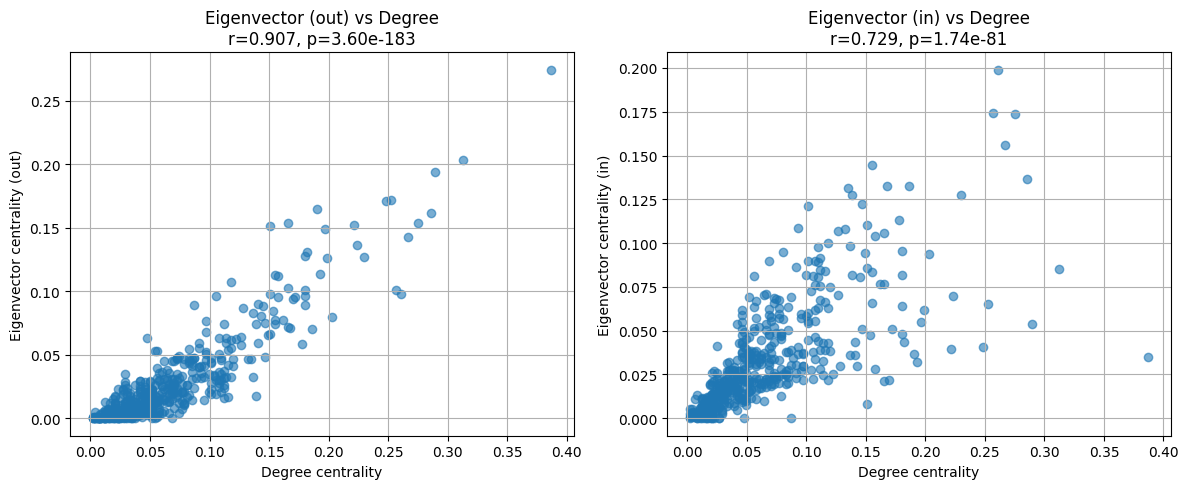

In [24]:



fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(deg, eig, alpha=0.6)
axes[0].set_xlabel("Degree centrality")
axes[0].set_ylabel("Eigenvector centrality (out)")
axes[0].set_title(f"Eigenvector (out) vs Degree\nr={r_eig_deg:.3f}, p={p_eig_deg:.2e}")
axes[0].grid(True)

axes[1].scatter(deg, eig_i, alpha=0.6)
axes[1].set_xlabel("Degree centrality")
axes[1].set_ylabel("Eigenvector centrality (in)")
axes[1].set_title(f"Eigenvector (in) vs Degree\nr={r_in:.3f}, p={p_in:.2e}")
axes[1].grid(True)

plt.tight_layout()
plt.show()


Based on the plot and the correlation metric, we see that degree and out eigenvector centrality is highly correlated for this network. This means that bands that have more connections tend to also be connected to more important nodes. (E.g. Beatles and Rolling Stones from the previous findings)

We also observe a slightly weaker correlation when we compare the eigenvector centrality for the in degrees with the degree centrality. This means that those nodes being referenced by popular nodes also tend to have higher degree.
These findings bring up the question of the network possibly being assortative, which we look into next.



Assortativity measures the tendency of nodes to connect to other nodes that are similar to them in some property. We investigate this tendency with the degrees and the length of content. We will use an undirected version of the graph for this.

In [25]:
# Convert to undirected graph for assortativity
undirected = network.to_undirected()

degree_assortativity = nx.degree_assortativity_coefficient(undirected)
print(f"Degree assortativity coefficient: {degree_assortativity:.4f}")

content_assortativity = nx.attribute_assortativity_coefficient(undirected, 'length_of_content')
print(f"\nLength of content assortativity coefficient: {content_assortativity:.4f}")

Degree assortativity coefficient: -0.0130

Length of content assortativity coefficient: -0.0027


In [26]:
# Visualize degree correlations
degrees = np.array([d for n, d in undirected.degree()])
neighbor_degrees = []
for node in undirected.nodes():
    # Get degrees of all neighbors
    nbr_deg = np.mean([undirected.degree(nbr) for nbr in undirected.neighbors(node)])
    neighbor_degrees.append(nbr_deg)
neighbor_degrees = np.array(neighbor_degrees)

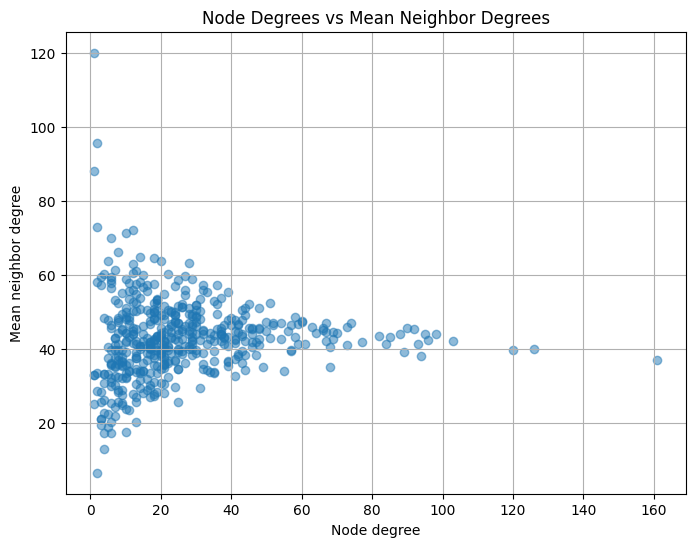

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(degrees, neighbor_degrees, alpha=0.5)
plt.xlabel("Node degree")
plt.ylabel("Mean neighbor degree")
plt.title("Node Degrees vs Mean Neighbor Degrees")
plt.grid(True)
plt.show()

The degree assortativity is -0.0130, which shows that there is no tendency of high degree artists linking to eachother (and low degree ones to eachother), which contradicts our assumptions.

The plot above illustrates this observation, as it is clearly visible that even though for the low degree nodes there is a larger spread, the mean neighbor degrees stay at around 40, without showing a tendency to increase with the node degree.

We also calculated the assortativity for the length of content. This also shows no tendency for longer pages linking to other longer pages. This is an important finding, with the fact in mind that we have already seen that the longer a page is, the more connections it tends to have.

Both of these findings suggest that connections are more based on relevance for the articles than popularity. This means that the connections are more "democratic" for the rock band network.

As a concluding step we created a visualization of the network, using a backbone to make the structure more visible

In [28]:
undirected_full = network.to_undirected()
# Extract giant connected component
components = list(nx.connected_components(undirected_full))
largest_cc = max(components, key=len)
Gcc = undirected_full.subgraph(largest_cc).copy()
print(f"GCC nodes: {Gcc.number_of_nodes()}, edges: {Gcc.number_of_edges()}")

GCC nodes: 484, edges: 6301


We use weights that are proportional to the edge betweenness centrality.

In [29]:
# Compute edge betweenness and renormalize to [1,100]
ebc = nx.edge_betweenness_centrality(Gcc, normalized=True)
vals = np.array(list(ebc.values()))
minv, maxv = float(vals.min()), float(vals.max())
if maxv > minv:
    renorm_w = {e: 1 + (v - minv) * (99.0 / (maxv - minv)) for e, v in ebc.items()}
else:
    renorm_w = {e: 1.0 for e in ebc}

In [30]:
# Assign weights
for (u, v), w in renorm_w.items():
    if Gcc.has_edge(u, v):
        Gcc[u][v]['weight'] = w

We use the solution of Michele Coscia for the disparity filter with a very few minor tweaks.
https://www.michelecoscia.com/?page_id=287

In [31]:
# Michele Coscia's backboning with some slight modifications (https://www.michelecoscia.com/?page_id=287)

import sys, warnings
import numpy as np
import pandas as pd
import networkx as nx
from collections import defaultdict
from scipy.stats import binom

def read(filename, column_of_interest, triangular_input = False, consider_self_loops = True, undirected = False, drop_zeroes = True, sep = "\t"):
   """Reads a field separated input file into the internal backboning format (a Pandas Dataframe).
   The input file should have three or more columns (default separator: tab).
   The input file must have a one line header with the column names.
   There must be two columns called 'src' and 'trg', indicating the origin and destination of the interaction.
   All other columns must contain integer or floats, indicating the edge weight.
   In case of undirected network, the edges have to be present in both directions with the same weights, or set triangular_input to True.

   Args:
   filename (str): The path to the file containing the edges.
   column_of_interest (str): The column name identifying the weight that will be used for the backboning.

   KWArgs:
   triangular_input (bool): Is the network undirected and are the edges present only in one direction? default: False
   consider_self_loops (bool): Do you want to consider self loops when calculating the backbone? default: True
   undirected (bool): Is the network undirected? default: False
   drop_zeroes (bool): Do you want to keep zero weighted connections in the network? Important: it affects methods based on degree, like disparity_filter. default: False
   sep (char): The field separator of the inout file. default: tab

   Returns:
   The parsed network data, the number of nodes in the network and the number of edges.
   """
   table = pd.read_csv(filename, sep = sep)
   table = table[["src", "trg", column_of_interest]]
   table.rename(columns = {column_of_interest: "nij"}, inplace = True)
   if drop_zeroes:
      table = table[table["nij"] > 0]
   if not consider_self_loops:
      table = table[table["src"] != table["trg"]]
   if triangular_input:
      table2 = table.copy()
      table2["new_src"] = table["trg"]
      table2["new_trg"] = table["src"]
      table2.drop("src", 1, inplace = True)
      table2.drop("trg", 1, inplace = True)
      table2 = table2.rename(columns = {"new_src": "src", "new_trg": "trg"})
      table = pd.concat([table, table2], axis = 0)
      table = table.drop_duplicates(subset = ["src", "trg"])
   original_nodes = len(set(table["src"]) | set(table["trg"]))
   original_edges = table.shape[0]
   if undirected:
      return table, original_nodes, original_edges / 2
   else:
      return table, original_nodes, original_edges

def thresholding(table, threshold):
   """Reads a preprocessed edge table and returns only the edges supassing a significance threshold.

   Args:
   table (pandas.DataFrame): The edge table.
   threshold (float): The minimum significance to include the edge in the backbone.

   Returns:
   The network backbone.
   """
   table = table.copy()
   if "sdev_cij" in table:
      return table[(table["score"] - (threshold * table["sdev_cij"])) > 0][["src", "trg", "nij", "score"]]
   else:
      return table[table["score"] > threshold][["src", "trg", "nij", "score"]]

def write(table, network, method, folder):
   if not table.empty and "src" in table:
      table.to_csv("%s/%s_%s.csv" % (folder, network, method), sep = "\t", index = False)
   else:
      warnings.warn("Incorrect/empty output. Nothing written on disk", RuntimeWarning)

def stability_jac(table1, table2):
   table1_edges = set(zip(table1["src"], table1["trg"]))
   table2_edges = set(zip(table2["src"], table2["trg"]))
   return float(len(table1_edges & table2_edges)) / len(table1_edges | table2_edges)

def stability_corr(table1, table2, method = "spearman", log = False, what = "nij"):
   corr_table = table1.merge(table2, on = ["src", "trg"])
   corr_table = corr_table[["%s_x" % what, "%s_y" % what]]
   if log:
      corr_table["%s_x" % what] = np.log(corr_table["%s_x" % what])
      corr_table["%s_y" % what] = np.log(corr_table["%s_y" % what])
   return corr_table["%s_x" % what].corr(corr_table["%s_y" % what], method = method)

def test_densities(table, start, end, step):
   if start > end:
      raise ValueError("start must be lower than end")
   steps = []
   x = start
   while x <= end:
      steps.append(x)
      x += step
   onodes = len(set(table["src"]) | set(table["trg"]))
   oedges = table.shape[0]
   oavgdeg = (2.0 * oedges) / onodes
   for s in steps:
      edge_table = thresholding(table, s)
      nodes = len(set(edge_table["src"]) | set(edge_table["trg"]))
      edges = edge_table.shape[0]
      avgdeg = (2.0 * edges) / nodes
      yield (s, nodes, (100.0 * nodes) / onodes, edges, (100.0 * edges) / oedges, avgdeg, avgdeg / oavgdeg)

def noise_corrected(table, undirected = False, return_self_loops = False, calculate_p_value = False):
   sys.stderr.write("Calculating NC score...\n")
   table = table.copy()
   src_sum = table.groupby(by = "src").sum()[["nij"]]
   table = table.merge(src_sum, left_on = "src", right_index = True, suffixes = ("", "_src_sum"))
   trg_sum = table.groupby(by = "trg").sum()[["nij"]]
   table = table.merge(trg_sum, left_on = "trg", right_index = True, suffixes = ("", "_trg_sum"))
   table.rename(columns = {"nij_src_sum": "ni.", "nij_trg_sum": "n.j"}, inplace = True)
   table["n.."] = table["nij"].sum()
   table["mean_prior_probability"] = ((table["ni."] * table["n.j"]) / table["n.."]) * (1 / table["n.."])
   if calculate_p_value:
      table["score"] = binom.cdf(table["nij"], table["n.."], table["mean_prior_probability"])
      return table[["src", "trg", "nij", "score"]]
   table["kappa"] = table["n.."] / (table["ni."] * table["n.j"])
   table["score"] = ((table["kappa"] * table["nij"]) - 1) / ((table["kappa"] * table["nij"]) + 1)
   table["var_prior_probability"] = (1 / (table["n.."] ** 2)) * (table["ni."] * table["n.j"] * (table["n.."] - table["ni."]) * (table["n.."] - table["n.j"])) / ((table["n.."] ** 2) * ((table["n.."] - 1)))
   table["alpha_prior"] = (((table["mean_prior_probability"] ** 2) / table["var_prior_probability"]) * (1 - table["mean_prior_probability"])) - table["mean_prior_probability"]
   table["beta_prior"] = (table["mean_prior_probability"] / table["var_prior_probability"]) * (1 - (table["mean_prior_probability"] ** 2)) - (1 - table["mean_prior_probability"])
   table["alpha_post"] = table["alpha_prior"] + table["nij"]
   table["beta_post"] = table["n.."] - table["nij"] + table["beta_prior"]
   table["expected_pij"] = table["alpha_post"] / (table["alpha_post"] + table["beta_post"])
   table["variance_nij"] = table["expected_pij"] * (1 - table["expected_pij"]) * table["n.."]
   table["d"] = (1.0 / (table["ni."] * table["n.j"])) - (table["n.."] * ((table["ni."] + table["n.j"]) / ((table["ni."] * table["n.j"]) ** 2)))
   table["variance_cij"] = table["variance_nij"] * (((2 * (table["kappa"] + (table["nij"] * table["d"]))) / (((table["kappa"] * table["nij"]) + 1) ** 2)) ** 2) 
   table["sdev_cij"] = table["variance_cij"] ** .5
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table = table[table["src"] <= table["trg"]]
   return table[["src", "trg", "nij", "score", "sdev_cij"]]

def doubly_stochastic(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating DST score...\n")
   table = table.copy()
   table2 = table.copy()
   original_nodes = len(set(table["src"]) | set(table["trg"]))
   table = pd.pivot_table(table, values = "nij", index = "src", columns = "trg", aggfunc = "sum", fill_value = 0) + .001
   row_sums = table.sum(axis = 1)
   attempts = 0
   while np.std(row_sums) > 1e-12:
      table = table.div(row_sums, axis = 0)
      col_sums = table.sum(axis = 0)
      table = table.div(col_sums, axis = 1)
      row_sums = table.sum(axis = 1)
      attempts += 1
      if attempts > 1000:
         warnings.warn("Matrix could not be reduced to doubly stochastic. See Sec. 3 of Sinkhorn 1964", RuntimeWarning)
         return pd.DataFrame()
   table = pd.melt(table.reset_index(), id_vars = "src")
   table = table[table["src"] < table["trg"]]
   table = table[table["value"] > 0].sort_values(by = "value", ascending = False)
   i = 0
   if undirected:
      G = nx.Graph()
      while nx.number_connected_components(G) != 1 or nx.number_of_nodes(G) < original_nodes:
         edge = table.iloc[i]
         G.add_edge(edge["src"], edge["trg"], weight = edge["value"])
         i += 1
   else:
      G = nx.DiGraph()
      while nx.number_weakly_connected_components(G) != 1 or nx.number_of_nodes(G) < original_nodes:
         edge = table.iloc[i]
         G.add_edge(edge["src"], edge["trg"], weight = edge["value"])
         i += 1
   table = pd.melt(nx.to_pandas_adjacency(G).reset_index(), id_vars = "index")
   table = table[table["value"] > 0]
   table.rename(columns = {"index": "src", "variable": "trg", "value": "cij"}, inplace = True)
   table["score"] = table["cij"]
   table = table.merge(table2[["src", "trg", "nij"]], on = ["src", "trg"])
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table = table[table["src"] <= table["trg"]]
   return table[["src", "trg", "nij", "score"]]

def disparity_filter(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating DF score...\n")
   table = table.copy()
   # safer version for pandas >=2.0
   table_sum = table.groupby("src", as_index=False)[["nij"]].sum().rename(columns={"nij": "nij_sum"})
   table_deg = table.groupby("src", as_index=False).agg({"trg": "count"}).rename(columns={"trg": "trg_count"})
   table = table.merge(table_sum, on="src", how="left")
   table = table.merge(table_deg, on="src", how="left")
   table["score"] = 1.0 - ((1.0 - (table["nij"] / table["nij_sum"])) ** (table["trg_count"] - 1))

   table["variance"] = (table["trg_count"] ** 2) * (((20 + (4.0 * table["trg_count"])) / ((table["trg_count"] + 1.0) * (table["trg_count"] + 2) * (table["trg_count"] + 3))) - ((4.0) / ((table["trg_count"] + 1.0) ** 2)))
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].max().reset_index()
      table_minvar = table.groupby(by = "edge")["variance"].min().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.merge(table_minvar, on = "edge", suffixes = ("_max", ""))
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", axis=1)
      table = table.drop("score_min", axis=1)
      table = table.drop("variance_max", axis=1)
   return table[["src", "trg", "nij", "score", "variance"]]

def high_salience_skeleton(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating HSS score...\n")
   table = table.copy()
   table["distance"] = 1.0 / table["nij"]
   nodes = set(table["src"]) | set(table["trg"])
   G = nx.from_pandas_edgelist(table, source = "src", target = "trg", edge_attr = "distance", create_using = nx.DiGraph())
   cs = defaultdict(float)
   for s in nodes:
      pred = defaultdict(list)
      dist = {t: float("inf") for t in nodes}
      dist[s] = 0.0
      Q = defaultdict(list)
      for w in dist:
         Q[dist[w]].append(w)
      S = []
      while len(Q) > 0:
         v = Q[min(Q.keys())].pop(0)
         S.append(v)
         for _, w, l in G.edges(nbunch = [v,], data = True):
            new_distance = dist[v] + l["distance"]
            if dist[w] > new_distance:
               Q[dist[w]].remove(w)
               dist[w] = new_distance
               Q[dist[w]].append(w)
               pred[w] = []
            if dist[w] == new_distance:
               pred[w].append(v)
         while len(S) > 0:
            w = S.pop()
            for v in pred[w]:
               cs[(v, w)] += 1.0
         Q = defaultdict(list, {k: v for k, v in Q.items() if len(v) > 0})
   table["score"] = table.apply(lambda x: cs[(x["src"], x["trg"])] / len(nodes), axis = 1)
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].sum().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", 1)
      table = table.drop("score_min", 1)
      table["score"] = table["score"] / 2.0
   return table[["src", "trg", "nij", "score"]]

def naive(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating Naive score...\n")
   table = table.copy()
   table["score"] = table["nij"]
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].sum().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", 1)
      table = table.drop("score_min", 1)
      table["score"] = table["score"] / 2.0
   return table[["src", "trg", "nij", "score"]]

def maximum_spanning_tree(table, undirected = False):
   sys.stderr.write("Calculating MST score...\n")
   table = table.copy()
   table["distance"] = 1.0 / table["nij"]
   G = nx.from_pandas_edgelist(table, source = "src", target = "trg", edge_attr = ["distance", "nij"])
   T = nx.minimum_spanning_tree(G, weight = "distance")
   table2 = nx.to_pandas_edgelist(T)
   table2 = table2[table2["nij"] > 0]
   table2.rename(columns = {"source": "src", "target": "trg", "nij": "score"}, inplace = True)
   table = table.merge(table2, on = ["src", "trg"])
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", 1)
   return table[["src", "trg", "nij", "score"]]


In [32]:
# Create edge table from Gcc
rows = []
for u, v, data in Gcc.edges(data=True):
    w = float(data.get('weight', 1.0))
    rows.append({'src': u, 'trg': v, 'nij': w})
    # duplicate for undirected edges
    rows.append({'src': v, 'trg': u, 'nij': w})

table = pd.DataFrame(rows)

# Ensure types for pandas >=2.0 compatibility
table['nij'] = table['nij'].astype(float)
table['src'] = table['src'].astype(str)
table['trg'] = table['trg'].astype(str)

In [33]:
df_table = disparity_filter(
    table.copy(),
    undirected=True,
    return_self_loops=False
)

alpha = 0.77
thr_table = thresholding(df_table, alpha)

Calculating DF score...


In [34]:
# Build networkx graph for backbone
G_b = nx.Graph()
G_b.add_nodes_from(Gcc.nodes(data=True))

In [35]:
for _, row in thr_table.iterrows():
    s = row['src']
    t = row['trg']
    score = row.get('score', None)
    if Gcc.has_edge(s, t):
        w = Gcc[s][t].get('weight', 1.0)
        G_b.add_edge(s, t, weight=w, score=score)

# Remove isolated ones
G_b = G_b.subgraph([n for n in G_b.nodes() if G_b.degree(n) > 0]).copy()
backbones_coscia = G_b
print(f"coscia alpha={alpha}: nodes={G_b.number_of_nodes()}, edges={G_b.number_of_edges()}")


coscia alpha=0.77: nodes=483, edges=1276


We found an alpha threshold of 0.77 to work the best for providing a structural overview, but still comprehendable.

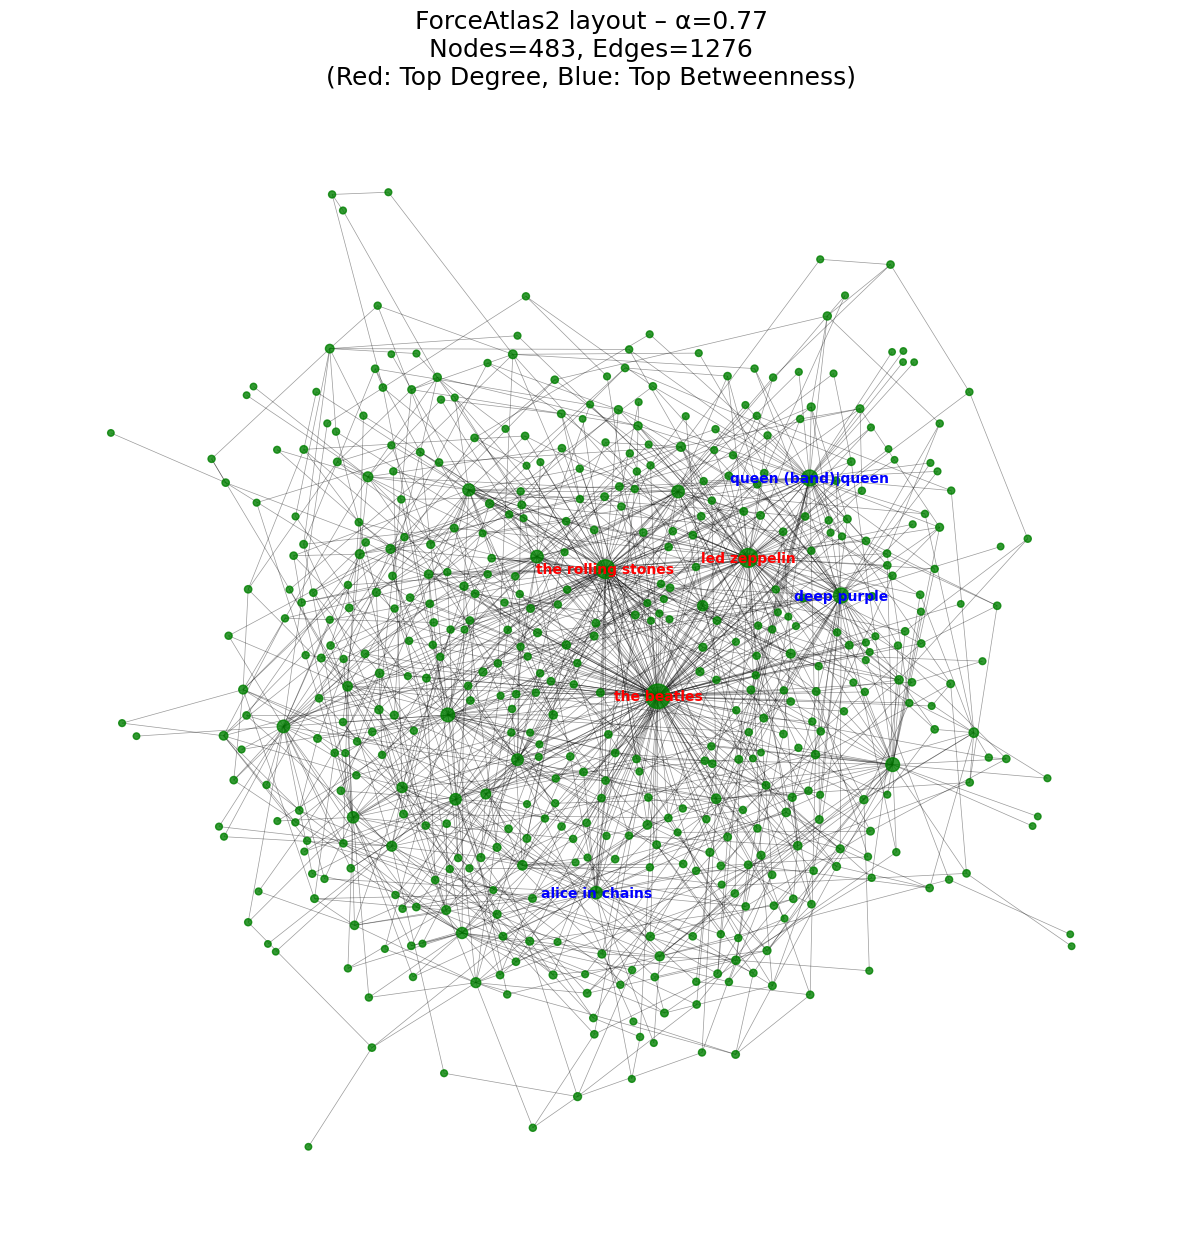

In [36]:
import networkx as nx
import matplotlib.pyplot as plt

G_b_plot = G_b.copy()
isolates = list(nx.isolates(G_b_plot))
G_b_plot.remove_nodes_from(isolates)

pos = nx.forceatlas2_layout(G_b_plot, max_iter=200, gravity=0.5)

# Node sizes proportional to degree
degrees = dict(G_b_plot.degree())
sizes = [20 + 2 * degrees[n] for n in G_b_plot.nodes()]

plt.figure(figsize=(15, 15))
nx.draw_networkx_nodes(G_b_plot, pos, node_size=sizes, node_color="green", alpha=0.8)
nx.draw_networkx_edges(G_b_plot, pos, alpha=0.4, width=0.5)

# Annotate top 3 nodes by degree
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:3]
for node, deg in top_nodes:
    x, y = pos[node]
    plt.text(x, y, str(node), fontsize=10, fontweight='bold', color='red',
             horizontalalignment='center', verticalalignment='center')
    
# Annotate top 3 nodes by betweenness centrality
top_nodes_betweenness = [node for node, _ in sorted_by_betweenness[:3]]
for node in top_nodes_betweenness:
    if node in pos:
        x, y = pos[node]
        plt.text(x, y - 0.03, str(node), fontsize=10, fontweight='bold', color='blue',
                 horizontalalignment='center', verticalalignment='center')

plt.title(f"ForceAtlas2 layout – α={alpha}\nNodes={G_b_plot.number_of_nodes()}, Edges={G_b_plot.number_of_edges()}\n(Red: Top Degree, Blue: Top Betweenness)", fontsize=18)
plt.axis("off")
plt.show()


We see the structure more clearly with the backbone visualization. The nodes with the top number of degrees (also present in our previous analysis steps) were also annotated. The structure shows that a few hubs are really defined compared to the rest of the network, the ones annotated by red being the top candidates for degree centrality.

The top candidates for betweenness centrality are also annotated with blue. Their gateway role is also observable, especially with Queen, as the size is not as large as the other hubs, but it has links from multiple directions with a lot of artists that are further away in the layout.